# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

Systemic Banking Risk Assesment
- who (to whom are you communicating): Senior JPMorgan Chase chief risk officer, Ashley Bacon, and CEO, Jamie Dimon, who oversee the economic risks. 
- what (what do you want your audiance to know or do): Accept the key finicial indicators idenitified that historical preceded well known banking crisis, and please recognize how some of the same indicators are present or not present in todays banking ecosystem. 
- how (how can you use date to help make your point): Idenitfy early key finicial indicators that illustrate the conditions before the 2008 crisis and the 2020 Covid pandemic. Then develop forcast models using the same key indicators for predicitng the probabaility of similar disasters occuring now. 

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

# Dataset used
- Theres many datasets in the [FRED-MD Database for Macroeconomic Research](https://www.stlouisfed.org/research/economists/mccracken/fred-databases), but I specifically used the FRED-MD_2024m12.numbers. which describes financial indicators like 'Retail and Food Services Sales' in December 2024. If I were to complete this project fully, I would pick quarterly data going back to 2008 so that I can track the key economic indicators before, during, and after the recessions.
- The [U.S. Recession Indicator (USREC)](https://fred.stlouisfed.org/series/USREC) dataset indicates if the year was a recession year or not a recession year by denoting the year with '1' for yes and '0' for no. This is helpful for enforcing why 2008 and 2020 should be more closely examined. 
- The [FDIC Statistics at a Glance](https://www.fdic.gov/quarterly-banking-profile/fdic-statistics-glance) provides information on different types of loans like 'Domestic Deposits' and 'Loans to Individuals', which can indicate consumer confidence in the economy. 
- The [Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset) dataset may be simulated credit bureau data, but because it specifies the types of loans the people took, we can cross reference with the FDIC Statistics and simulate people defaulting using the credit risk dataset to model the population. 


For this homework Im looking at just one month of data from FRED-MD Database for Macroeconomic Research. 

### - Summarize the datasets using info() and describe()


In [2]:
data = pd.read_csv("/Users/udaya/Downloads/Historical-vintages-of-FRED-MD-2015-01-to-2024-12/FRED-MD_2024m12.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Columns: 127 entries, sasdate to VIXCLSx
dtypes: float64(103), int64(23), object(1)
memory usage: 785.9+ KB


In [4]:
data.describe()

,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
count,792.000000,792.000000,792.000000,7.910000e+02,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,...,792.000000,792.000000,792.000000,792.000000,792.000000,638.000000,791.000000,791.000000,792.000000,750.000000
mean,9547.034388,8130.542803,56.544340,8.224117e+05,222509.456076,67.560177,71.804264,70.581599,79.081315,66.653835,...,63.075617,53.711013,12.713561,14.756010,11.725492,85.019122,138221.790329,353128.169987,1331.897868,19.277022
std,5063.517898,4011.031615,30.668647,3.855208e+05,189010.037672,26.915001,27.268114,27.537838,23.542982,28.718980,...,31.120557,34.223879,7.959663,8.931801,7.155517,13.442433,140306.181759,338194.732904,1483.113646,7.096851
min,5.000000,5.000000,5.000000,5.000000e+00,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,6.000000,6.000000,2.130000,2.450000,2.040000,2.000000,6.000000,6.000000,6.000000,1.000000
25%,5145.454000,4569.650000,28.907750,4.877999e+05,50691.054080,44.904150,47.042050,44.855025,61.332075,42.170650,...,32.665750,19.197250,5.105000,6.785000,4.702500,75.000000,10811.000000,34131.000000,186.727850,14.261675
50%,8331.325500,7262.200000,48.330000,7.200715e+05,161847.549500,62.589400,71.524600,69.607650,80.995550,61.171950,...,67.132000,51.702000,11.860000,13.685000,11.255000,88.950000,80546.000000,189012.920000,720.603650,17.624250
75%,13766.290250,11448.950000,84.203250,1.176456e+06,358024.750000,95.334100,99.273350,98.456325,100.474200,97.597275,...,91.199250,83.747500,19.230000,21.760000,17.707500,94.700000,267126.120000,728821.575000,2084.900000,22.526075
max,22850.332000,16433.700000,122.173000,1.541305e+06,724609.000000,104.103800,110.212000,108.675800,111.757500,109.816700,...,120.190000,129.363000,31.630000,36.220000,28.300000,112.000000,554377.250000,949306.220000,5831.233000,62.964800


In [5]:
data = data.iloc[1:]

In [6]:
data

,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
1,1/1/1959,2583.560,2426.0,15.188,2.766768e+05,18235.77392,21.9616,23.3868,22.2620,31.6664,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.00,12298.00,84.2043,NaN
2,2/1/1959,2593.596,2434.8,15.346,2.787140e+05,18369.56308,22.3917,23.7024,22.4549,31.8987,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.00,12298.00,83.5280,NaN
3,3/1/1959,2610.396,2452.7,15.491,2.777753e+05,18523.05762,22.7142,23.8459,22.5651,31.8987,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.00,12349.00,81.6405,NaN
4,4/1/1959,2627.446,2470.0,15.435,2.833627e+05,18534.46600,23.1981,24.1903,22.8957,32.4019,...,18.300,10.221,2.16,2.47,2.08,NaN,6620.00,12484.00,81.8099,NaN
5,5/1/1959,2642.720,2486.4,15.622,2.853072e+05,18679.66354,23.5476,24.3911,23.1161,32.5567,...,18.280,10.238,2.17,2.48,2.08,95.3,6753.00,12646.00,80.7315,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,7/1/2024,19988.217,16306.3,120.966,1.529744e+06,710851.00000,102.5340,100.5549,100.3012,101.3681,...,119.776,127.972,31.20,35.70,27.96,66.4,548691.61,930374.96,5278.3525,14.4084
788,8/1/2024,20007.209,16322.1,121.052,1.530317e+06,710038.00000,103.0831,101.0481,101.0128,102.2410,...,119.653,128.291,31.26,35.81,27.97,67.9,551667.22,933066.90,5327.6461,19.6750
789,9/1/2024,20044.142,16333.7,121.690,1.541305e+06,716388.00000,102.5283,100.1897,99.8299,101.6286,...,119.220,128.682,31.44,36.00,28.11,70.1,553347.06,934283.59,5368.5924,17.6597
790,10/1/2024,20131.843,16394.9,121.837,1.539243e+06,719676.00000,102.1123,99.5930,99.0546,101.5048,...,119.073,129.148,31.57,36.22,28.18,70.5,554377.25,937299.96,5407.4120,19.9478


I removed the first one row because it had transformations that could be applied to the dataset if the dataset were to be used for other types of analysis. Afterwards, theres 127 columns, which represent the finical indicators, and 791 rows, which represent months, in this dataset. 103 columns are floats, 23 are ints, and 1 is in text. The date 'sasdate' is in test when it should be a datetype so I'm going to transform it. 

In [7]:
try:
    data["sasdate"] = pd.to_datetime(data["sasdate"], format='%m/%d/%Y')
    print("It worked!")
except ValueError as e:
    print(f"ValueError for sasdate: {e}")

It worked!


### - Are there any duplicate rows?

In [8]:
print("Duplicated row numbers: ", data.index[data.duplicated(keep=False)].tolist())
data = data.drop_duplicates()

Duplicated row numbers:  []


Theres no duplicate rows as expected. The date column would alone ensure there are no duplicates.

### - Are there any duplicate values in a given column (when this would be inappropriate?)

In [9]:
appendix = pd.read_csv('/Users/udaya/Downloads/FRED-MD Appendix/FRED-MD_updated_appendix.csv', sep=",", encoding='cp1252')

In [20]:
for x in data:
    if data[x].is_unique == True:
        print(x, "is unique")
for x in data:
    if data[x].is_unique == False:
        print(x, " is not unique: ", appendix.loc[appendix['fred'] == x, 'description'])


sasdate is unique
RPI is unique
CMRMTSPLx is unique
AMDMUOx is unique
M2SL is unique
BUSLOANS is unique
REALLN is unique
NONREVSL is unique
CONSPI is unique
S&P PE ratio is unique
INVEST is unique
W875RX1  is not unique:  1    Real personal income ex transfer receipts
Name: description, dtype: object
DPCERA3M086SBEA  is not unique:  2    Real personal consumption expenditures
Name: description, dtype: object
RETAILx  is not unique:  4    Retail and Food Services Sales
Name: description, dtype: object
INDPRO  is not unique:  5    IP Index
Name: description, dtype: object
IPFPNSS  is not unique:  6    IP: Final Products and Nonindustrial Supplies
Name: description, dtype: object
IPFINAL  is not unique:  7    IP: Final Products (Market Group)
Name: description, dtype: object
IPCONGD  is not unique:  8    IP: Consumer Goods
Name: description, dtype: object
IPDCONGD  is not unique:  9    IP: Durable Consumer Goods
Name: description, dtype: object
IPNCONGD  is not unique:  10    IP: Nondurab

The unique values are:
- sasdate: Date. Will be unique because theres a date per month. 
- RPI: Real Personal Income. Income varys per person. 
- CMRMTSPLx: Manufacturing and trade industry sale. Every month is goin to be differnet. 
- AMDMUOx: Unfilled Orders for Durable Goods.
- M2SL: M2 Money Stock, which acording to google "includes M1 – which is comprised of cash outside of the private banking system plus current account deposits – while also including capital in savings accounts, money market accounts and retail mutual funds, and time deposits of under $100,000."
- BUSLOANS: Commercial and Industrial Loans
- REALLN: Real Estate Loans at All Commercial Banks
- NONREVSL: Total Nonrevolving Credit, which acording to google
 is "a loan where a specific amount of money is borrowed all at once and repaid over a set term"
- CONSPI: Nonrevolving consumer credit to Personal Income
- S&P PE ratio: S&P’s Composite Common Stock: Price-Earnings Ratio
- INVEST: Securities in Bank Credit at All Commercial Banks

It makes sense for these values to be unique because they only occur once or are influenced by so many other factors. The features that do have duplicates are becuse they are not as unique. Sometimes they can be the same amount between months like Retail and Food Services Sales. The nonunique features are printed above. 

### - What are the mean, median, and mode of each column?

In [23]:
for x in data:
    print("Feature: ", x)
    print("Mean: ", data[x].mean())
    print("Median: ", data[x].median())
    print("Mode: ", data[x].mode())
    print("      ")

Feature:  sasdate
Mean:  1991-12-01 05:42:15.018963328
Median:  1991-12-01 00:00:00
Mode:  0     1959-01-01
1     1959-02-01
2     1959-03-01
3     1959-04-01
4     1959-05-01
         ...    
786   2024-07-01
787   2024-08-01
788   2024-09-01
789   2024-10-01
790   2024-11-01
Name: sasdate, Length: 791, dtype: datetime64[ns]
      
Feature:  RPI
Mean:  9559.097642225031
Median:  8365.723
Mode:  0       2583.560
1       2593.596
2       2610.396
3       2627.446
4       2634.369
         ...    
786    20044.142
787    20131.843
788    20163.284
789    20516.535
790    22850.332
Name: RPI, Length: 791, dtype: float64
      
Feature:  W875RX1
Mean:  8140.815297092288
Median:  7262.7
Mode:  0    2477.7
Name: W875RX1, dtype: float64
      
Feature:  DPCERA3M086SBEA
Mean:  56.60950316055626
Median:  48.363
Mode:  0    28.279
1    85.486
Name: DPCERA3M086SBEA, dtype: float64
      
Feature:  CMRMTSPLx
Mean:  823452.7264536708
Median:  720171.2395
Mode:  0      2.659352e+05
1      2.677102e+

The code above shows the mean, median, and mode for all columns. Some columns have multiple modes if they all appeared the same amount of times. 

### - Are there any missing or null values?
### - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

In [56]:
data.isnull().sum()

sasdate              0
RPI                  0
W875RX1              0
DPCERA3M086SBEA      0
CMRMTSPLx            1
                  ... 
UMCSENTx           154
DTCOLNVHFNM          1
DTCTHFNM             1
INVEST               0
VIXCLSx             42
Length: 127, dtype: int64

Some rows have 0, 1, or a lot of missing values like "UMCSENTx", which is the Consumer Sentiment Index. This feaure is mising 154 rows but is important for gauging the consumer's emotions so I will remove all rows with misisng data. 

In [57]:
data = data.dropna()

In [59]:
data.isnull().sum()

sasdate            0
RPI                0
W875RX1            0
DPCERA3M086SBEA    0
CMRMTSPLx          0
                  ..
UMCSENTx           0
DTCOLNVHFNM        0
DTCTHFNM           0
INVEST             0
VIXCLSx            0
Length: 127, dtype: int64

### - Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

In [72]:
data.describe()

,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
count,391,391.000000,391.000000,391.000000,3.910000e+02,391.00000,391.000000,391.000000,391.000000,391.000000,...,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000
mean,2008-05-05 13:19:10.895140608,13832.003059,11567.872634,82.890670,1.164382e+06,376861.56266,91.854568,96.395732,95.462907,99.848822,...,89.676179,83.100504,19.381918,22.118670,17.795780,85.744757,246784.487673,647142.638568,2402.838676,19.791939
min,1992-02-01 00:00:00,8444.994000,7290.100000,49.123000,7.188891e+05,163721.00000,61.919200,70.425800,68.647300,80.286700,...,67.191000,52.129000,11.890000,13.670000,11.300000,50.000000,58381.000000,189752.080000,744.154700,10.078500
25%,2000-03-16 12:00:00,11551.748000,10103.100000,68.441000,1.051674e+06,271707.00000,87.925650,95.239700,94.348150,98.089750,...,75.502500,64.717500,15.135000,17.330000,14.195000,76.050000,136804.680000,425618.195000,1156.951150,13.801600
50%,2008-05-01 00:00:00,13762.811000,11447.300000,84.200000,1.177581e+06,357879.00000,95.507200,99.281300,98.498700,100.496100,...,90.917000,83.671000,19.210000,21.740000,17.690000,88.500000,267241.560000,729225.720000,2083.919700,17.533100
75%,2016-06-16 00:00:00,16133.405000,13314.750000,97.210500,1.331964e+06,458134.50000,100.545900,101.053050,101.016150,102.878350,...,101.770500,97.688500,22.640000,26.070000,20.490000,95.550000,309297.050000,830500.990000,3226.310350,24.187550
max,2024-09-01 00:00:00,22850.332000,16333.700000,121.690000,1.541305e+06,716388.00000,104.103800,110.212000,108.675800,111.757500,...,120.190000,128.682000,31.440000,36.000000,28.110000,112.000000,553347.060000,949306.220000,5831.233000,62.964800
std,NaN,3301.225636,2484.598114,19.465046,2.137305e+05,143501.54966,11.333405,8.972065,9.358440,6.453933,...,15.421557,20.241845,5.016938,5.872769,4.221498,13.446171,121080.320718,232943.807167,1410.098035,8.107304


Theres no std for sasdate becuse its not possible to calculate one for a date. The other column's valuesa are not in relation to each other sinice they are measurements. Luckly we know they are not missing (anymore). 

### - Encode any categorical variables (e.g. with one-hot encoding.)

No categorial data, only datetime and numbers. 

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

This dataset is usable and only 1 of the many many sets available that I can string together to create the master set. I will have to string togetehr the datasets from 2008 to 2020 but that will not be hard with python. Lots of features can be predicted like unemployment rate, which is a helpful economic indicator. 

Text(0.5, 1.0, 'Unemployment rate counts')

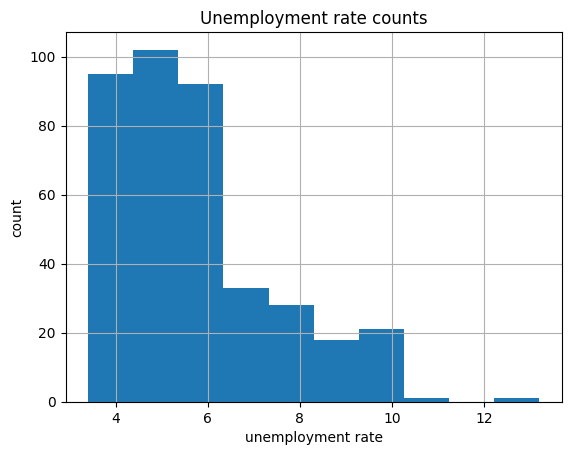

In [79]:
data['UNRATE'].hist()
plt.xlabel("unemployment rate")
plt.ylabel("count")
plt.title("Unemployment rate counts")

Above, the unemployment rate looks to have a bit of a class imballance since the rates tend to be lower. This is expected as the unemployment rate is very very high only rarely. This imbalance will hopefully not skew the models as the rows with very hgh unemployment rates need to be kept in the dataset.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

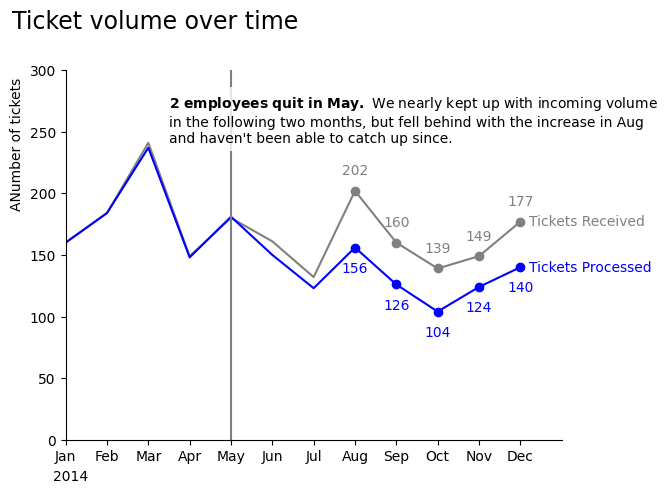

In [11]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
number_of_tickets_received = [160, 184, 241, 149, 180, 161, 132, 202, 160, 139, 149, 177]
number_of_tickets_processed = [160, 184, 237, 148, 181, 150, 123, 156, 126, 104, 124, 140]
plt.plot(months, number_of_tickets_received, color = "gray")
plt.plot(months, number_of_tickets_processed, color="blue")
plt.title("Ticket volume over time", fontsize=17, x = .18, pad = 30)
plt.ylabel("ANumber of tickets", y=.8) 
plt.ylim(bottom=0, top = 300)
plt.xlabel("2014", x=0.01) 
plt.margins(x=0)
plt.axvline(x = 4, color ='gray')
plt.text(2.5, 280, r"$\bf{2\ employees\ quit\ in\ May.}$ " "We nearly kept up with incoming volume\n" "in the following two months, but fell behind with the increase in Aug\n" "and haven't been able to catch up since.", ha= 'left', va = 'top', bbox=dict(facecolor='white', alpha =0.8, edgecolor='none'))
for i in range(7,12): 
    plt.text(i, number_of_tickets_received[i] + 13, str(number_of_tickets_received[i]), ha='center', color='grey') 
    plt.text(i, number_of_tickets_processed[i] - 20, str(number_of_tickets_processed[i]), ha='center', color='blue')
    plt.scatter(i, number_of_tickets_received[i], color='grey')
    plt.scatter(i, number_of_tickets_processed[i], color='blue')
plt.text(11.2, number_of_tickets_received[-1], "Tickets Received", color='grey', va='center') 
plt.text(11.2, number_of_tickets_processed[-1], "Tickets Processed", color='blue', va='center')
plt.xlim(right = 12)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()